**Setup dan Import Library**

In [8]:
import os
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
import matplotlib.cm as cm
import random

from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score, precision_score

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

source_path = '/content/drive/MyDrive/MangoLeafBD.zip'  # Sesuaikan nama file di Drive
dataset_dir = '/content/dataset_local'

print("\n--- Menyiapkan Dataset ---")
if not os.path.exists(dataset_dir):
    if source_path.endswith('.zip'):
        print(f"Mengekstrak {source_path} ke {dataset_dir}...")
        with zipfile.ZipFile(source_path, 'r') as zip_ref:
            zip_ref.extractall(dataset_dir)
    else:
        print(f"Menyalin folder dari {source_path}...")
        !rsync -ah --progress "{source_path}/" "{dataset_dir}/"
else:
    print("Folder dataset sudah ada, melewati ekstraksi.")

print(f"✅ Dataset siap di: {dataset_dir}")

sns.set(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Menyiapkan Dataset ---
Folder dataset sudah ada, melewati ekstraksi.
✅ Dataset siap di: /content/dataset_local


**DataFrame**

Total Gambar: 4000
Kelas Ditemukan: ['Die Back' 'Powdery Mildew' 'Anthracnose' 'Healthy' 'Bacterial Canker'
 'Cutting Weevil' 'Gall Midge' 'Sooty Mould']


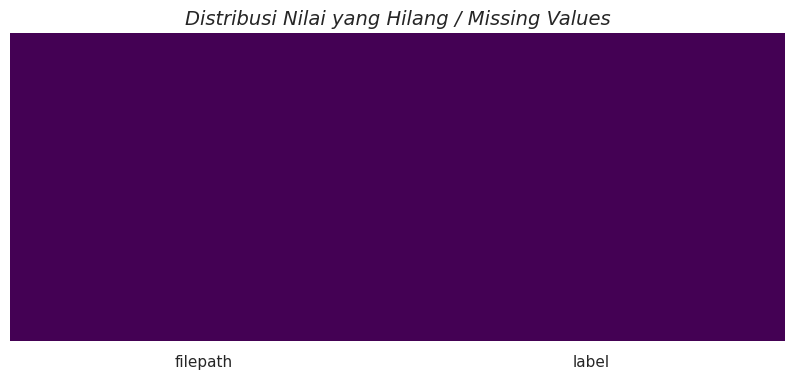

In [9]:
filepaths = []
labels = []

for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            filepaths.append(os.path.join(root, file))
            labels.append(os.path.basename(root))

df = pd.DataFrame({'filepath': filepaths, 'label': labels})

if len(df) == 0:
    raise ValueError("Error: Tidak ada gambar ditemukan!")

print(f"Total Gambar: {len(df)}")
print(f"Kelas Ditemukan: {df['label'].unique()}")

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Distribusi Nilai yang Hilang / Missing Values', fontsize=14, style='italic')
plt.show()

**Visualisasi Data (EDA)**

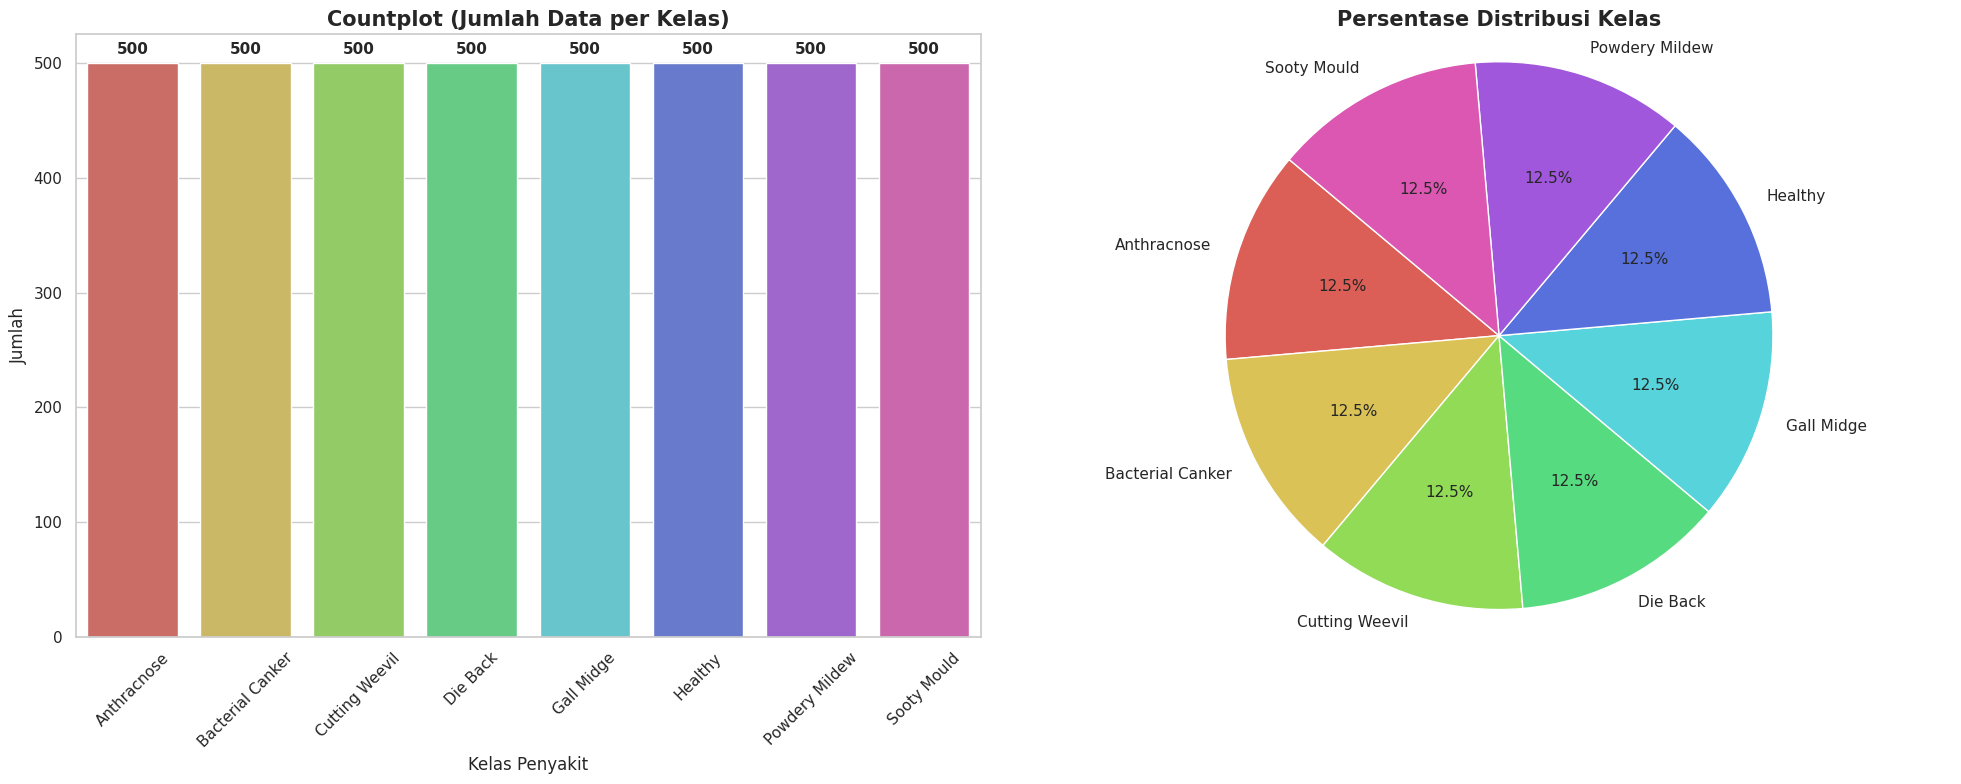


--- Rincian Jumlah Data per Kelas ---
Jenis 'Anthracnose' memiliki 500 gambar
Jenis 'Bacterial Canker' memiliki 500 gambar
Jenis 'Cutting Weevil' memiliki 500 gambar
Jenis 'Die Back' memiliki 500 gambar
Jenis 'Gall Midge' memiliki 500 gambar
Jenis 'Healthy' memiliki 500 gambar
Jenis 'Powdery Mildew' memiliki 500 gambar
Jenis 'Sooty Mould' memiliki 500 gambar


In [10]:

label_counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='hls')
plt.title('Countplot (Jumlah Data per Kelas)', fontsize=15, fontweight='bold')
plt.xlabel('Kelas Penyakit', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=45)
for i, count in enumerate(label_counts.values):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('hls', len(label_counts)),
        textprops={'fontsize': 11})
plt.title('Persentase Distribusi Kelas', fontsize=15, fontweight='bold')
plt.axis('equal')

plt.tight_layout()
plt.show()

print("\n--- Rincian Jumlah Data per Kelas ---")
for label, count in label_counts.items():
    print(f"Jenis '{label}' memiliki {count} gambar")

Visuali Data


--- Menampilkan Histogram Warna Sampel Acak ---


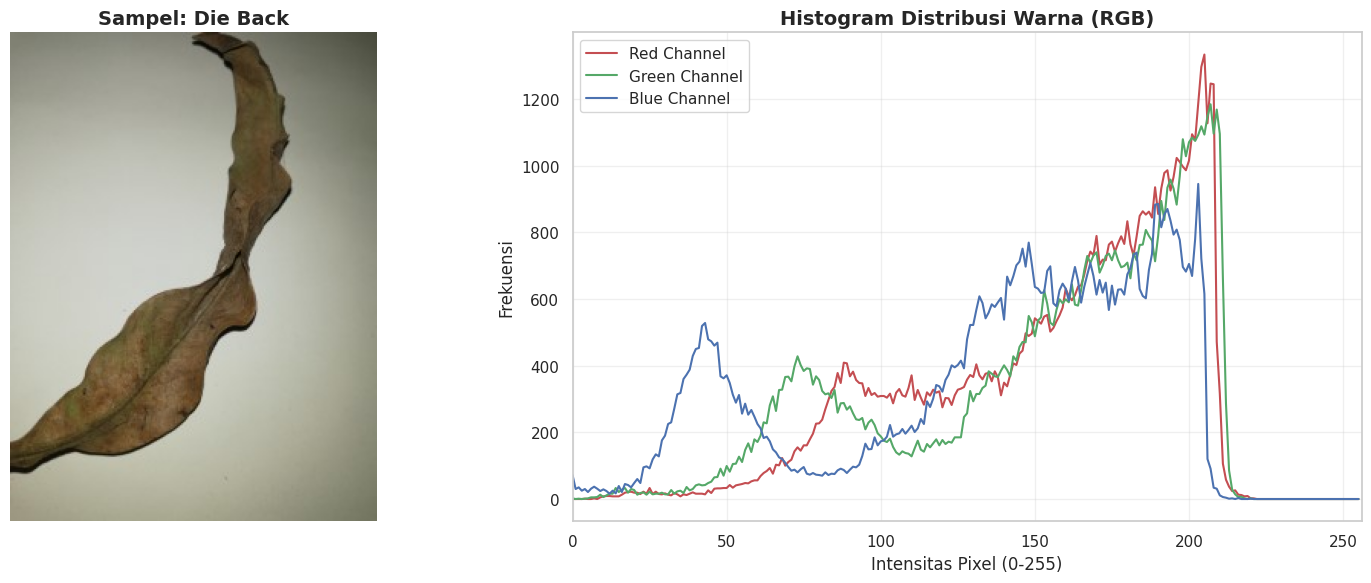

In [11]:
def show_color_histogram(df):
    random_index = random.randint(0, len(df) - 1)
    sample_path = df.iloc[random_index]['filepath']
    sample_label = df.iloc[random_index]['label']

    img = cv2.imread(sample_path)
    if img is None:
        print(f"Gagal membaca gambar: {sample_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(f"Sampel: {sample_label}", fontsize=14, fontweight='bold')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    colors = ('r', 'g', 'b')
    labels = ('Red Channel', 'Green Channel', 'Blue Channel')

    for i, color in enumerate(colors):
        hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
        plt.plot(hist, color=color, label=labels[i])
        plt.xlim([0, 256])

    plt.title('Histogram Distribusi Warna (RGB)', fontsize=14, fontweight='bold')
    plt.xlabel('Intensitas Pixel (0-255)')
    plt.ylabel('Frekuensi')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n--- Menampilkan Histogram Warna Sampel Acak ---")
show_color_histogram(df)

**Membagi Data Traning/Val/Testing dan Augmentasi Data**

In [12]:
train_df, temp_df = train_test_split(df, train_size=0.8, shuffle=True, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, train_size=0.5, shuffle=True, random_state=42, stratify=temp_df['label'])

print(f"\nJumlah Data Training   : {len(train_df)}")
print(f"Jumlah Data Validation : {len(val_df)}")
print(f"Jumlah Data Testing    : {len(test_df)}")

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode='rgb', class_mode='categorical', shuffle=True)
val_generator = test_datagen.flow_from_dataframe(val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode='rgb' , class_mode='categorical', shuffle=False)
test_generator = test_datagen.flow_from_dataframe(test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode='rgb' , class_mode='categorical', shuffle=False)


Jumlah Data Training   : 3200
Jumlah Data Validation : 400
Jumlah Data Testing    : 400
Found 3200 validated image filenames belonging to 8 classes.
Found 400 validated image filenames belonging to 8 classes.
Found 400 validated image filenames belonging to 8 classes.


**Visualisasi Traning Data**

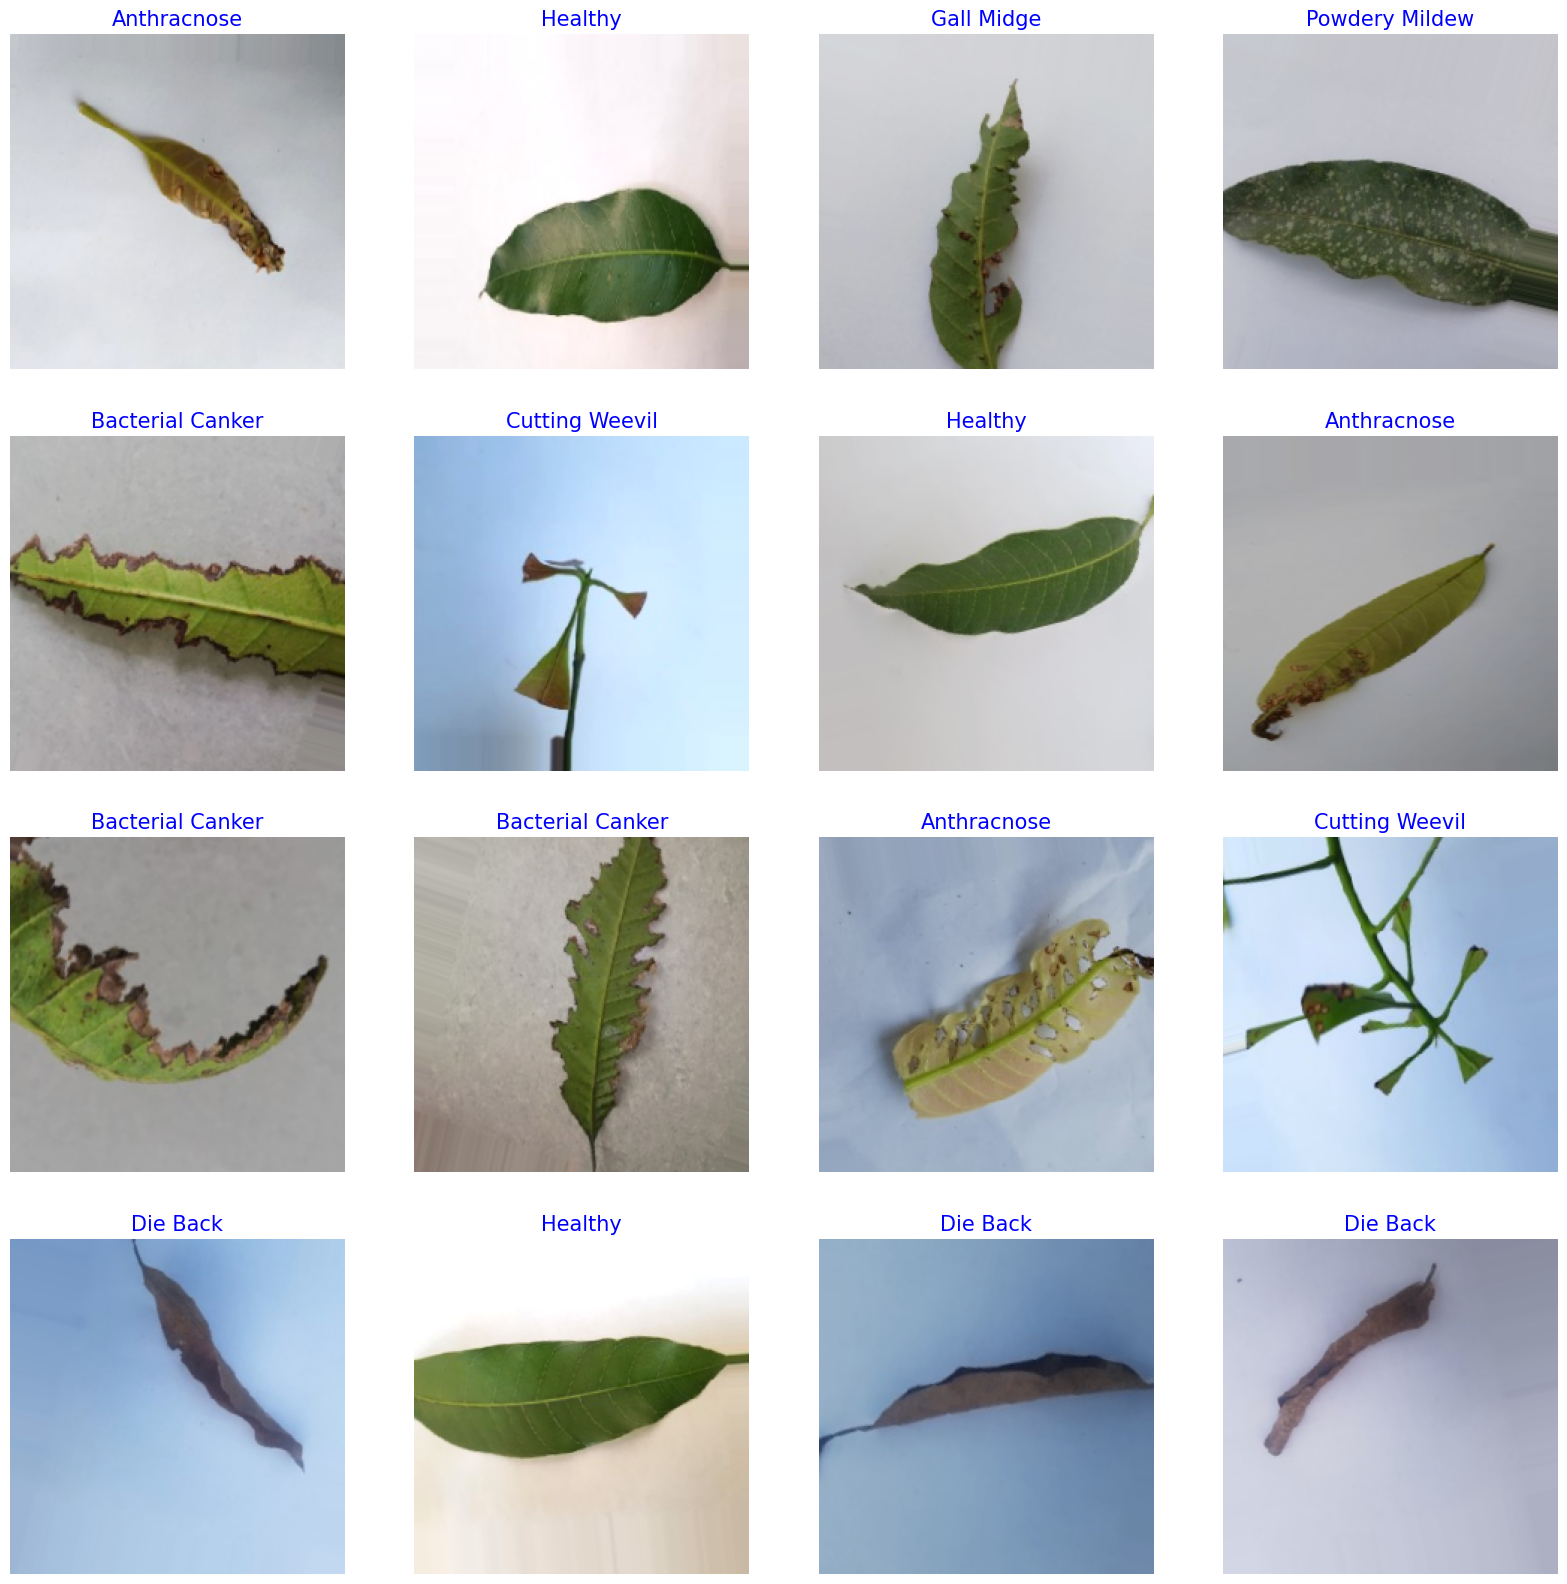

In [13]:
g_dict = train_generator.class_indices
classes = list(g_dict.keys())

images, labels = next(train_generator)

plt.figure(figsize=(20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i]
    image = image / 255.0

    plt.imshow(image)

    index = np.argmax(labels[i])
    class_name = classes[index]

    plt.title(class_name, color='blue', fontsize=15)
    plt.axis('off')

plt.show()

**Traning Model**

In [ ]:
# 1. Load Base Model (EfficientNetB0)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 2. Tambahkan Custom Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
predictions = Dense(8, activation='softmax')(x)

# 3. Gabungkan menjadi satu model
model = Model(inputs=base_model.input, outputs=predictions)


# --- TAHAP 1: TRAINING BASE MODEL BEKU (Feature Extraction) ---
print("\n🚀 MULAI TRAINING TAHAP 1 (Base Model Beku)...")

base_model.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)


# --- TAHAP 2: FINE TUNING ---
print("\n🔓 MULAI TRAINING TAHAP 2 (Fine Tuning)...")

base_model.trainable = True

# Freeze layer awal, hanya latih 30 layer terakhir (Sesuai gambar)
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Compile ulang dengan learning rate yang lebih kecil
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[
        EarlyStopping(patience=8, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=3, verbose=1),
        ModelCheckpoint('Model_Mangga.keras', save_best_only=True)
    ]
)


🚀 MULAI TRAINING TAHAP 1 (Base Model Beku)...
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 586ms/step - accuracy: 0.6832 - loss: 0.9507 - val_accuracy: 0.9725 - val_loss: 0.3094
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 46s 465ms/step - accuracy: 0.9686 - loss: 0.1130 - val_accuracy: 0.9850 - val_loss: 0.1117
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 448ms/step - accuracy: 0.9742 - loss: 0.0792 - val_accuracy: 0.9925 - val_loss: 0.0470
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 46s 460ms/step - accuracy: 0.9813 - loss: 0.0568 - val_accuracy: 0.9850 - val_loss: 0.0344
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 47s 468ms/step - accuracy: 0.9916 - loss: 0.0403 - val_accuracy: 0.9900 - val_loss: 0.0296
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 454ms/step - accuracy: 0.9873 - loss: 0.0345 - val_accuracy: 0.9900 - val_loss: 0.0220
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 47s 466ms/step - accuracy: 0.9911 - loss: 0.0324 - val_accuracy: 0.9950 - val_loss: 0.0141
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━

**Evaluasi**

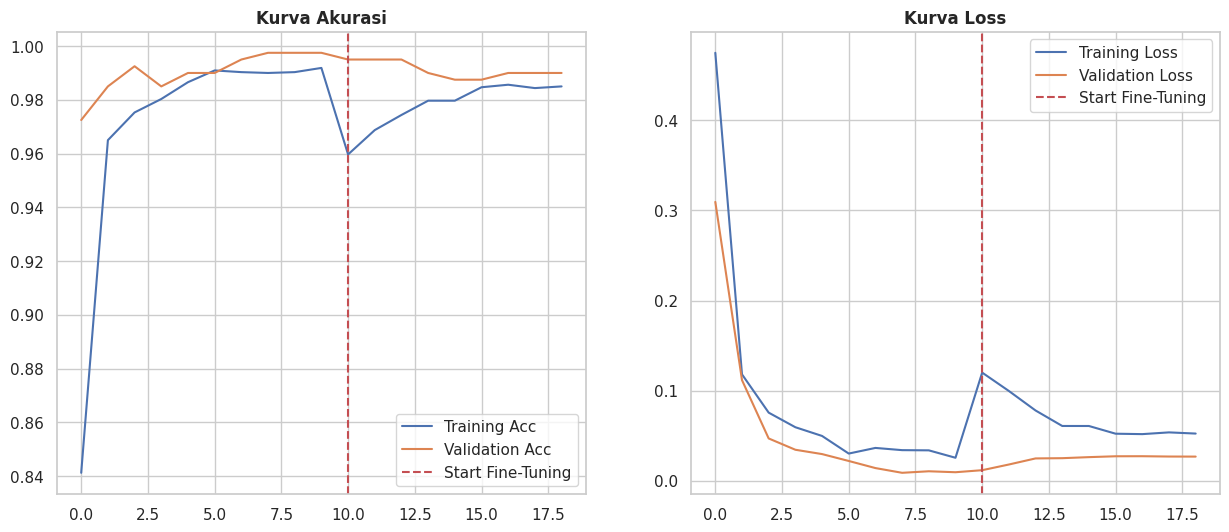


📊 Mengevaluasi Data Uji...
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 657ms/step
                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00        50
Bacterial Canker       1.00      1.00      1.00        50
  Cutting Weevil       1.00      1.00      1.00        50
        Die Back       1.00      1.00      1.00        50
      Gall Midge       1.00      1.00      1.00        50
         Healthy       1.00      1.00      1.00        50
  Powdery Mildew       0.98      1.00      0.99        50
     Sooty Mould       1.00      0.98      0.99        50

        accuracy                           1.00       400
       macro avg       1.00      1.00      1.00       400
    weighted avg       1.00      1.00      1.00       400



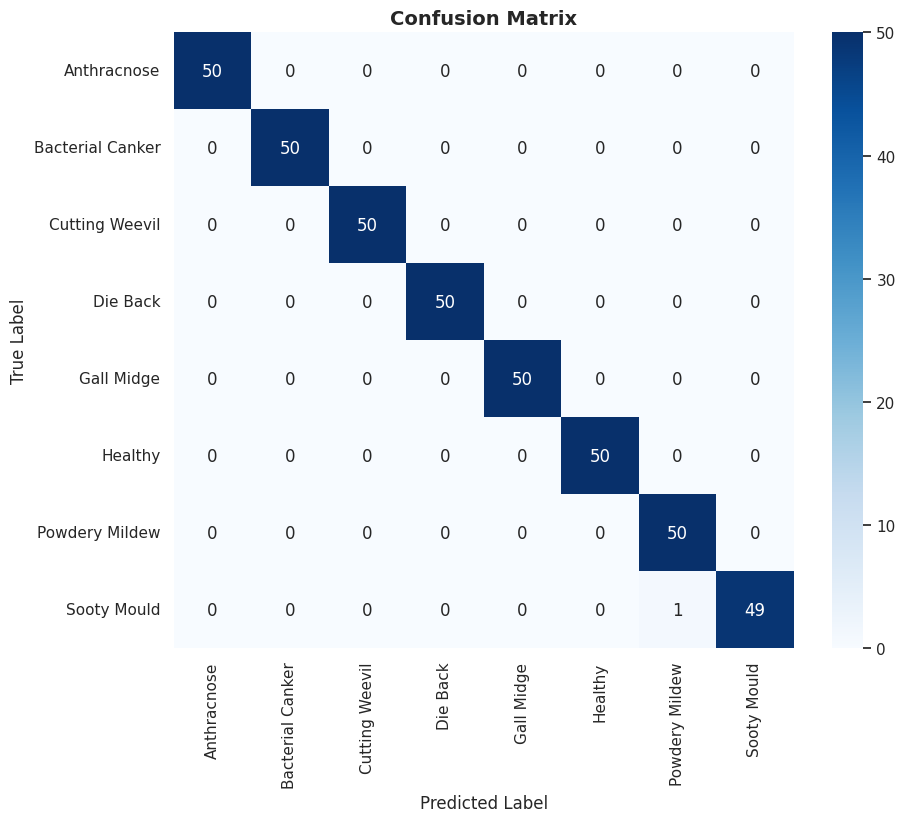

In [16]:
# Gabung History
acc = history_1.history['accuracy'] + history_2.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
loss = history_1.history['loss'] + history_2.history['loss']
val_loss = history_1.history['val_loss'] + history_2.history['val_loss']

# Plot Kurva
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Acc')
plt.plot(val_acc, label='Validation Acc')
plt.axvline(x=len(history_1.history['accuracy']), color='r', linestyle='--', label='Start Fine-Tuning')
plt.title('Kurva Akurasi', fontweight='bold')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=len(history_1.history['loss']), color='r', linestyle='--', label='Start Fine-Tuning')
plt.title('Kurva Loss', fontweight='bold')
plt.legend()
plt.show()

# Evaluasi Data Uji
print("\n📊 Mengevaluasi Data Uji...")
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Laporan Klasifikasi
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

**Visualisasi Prediksi**

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


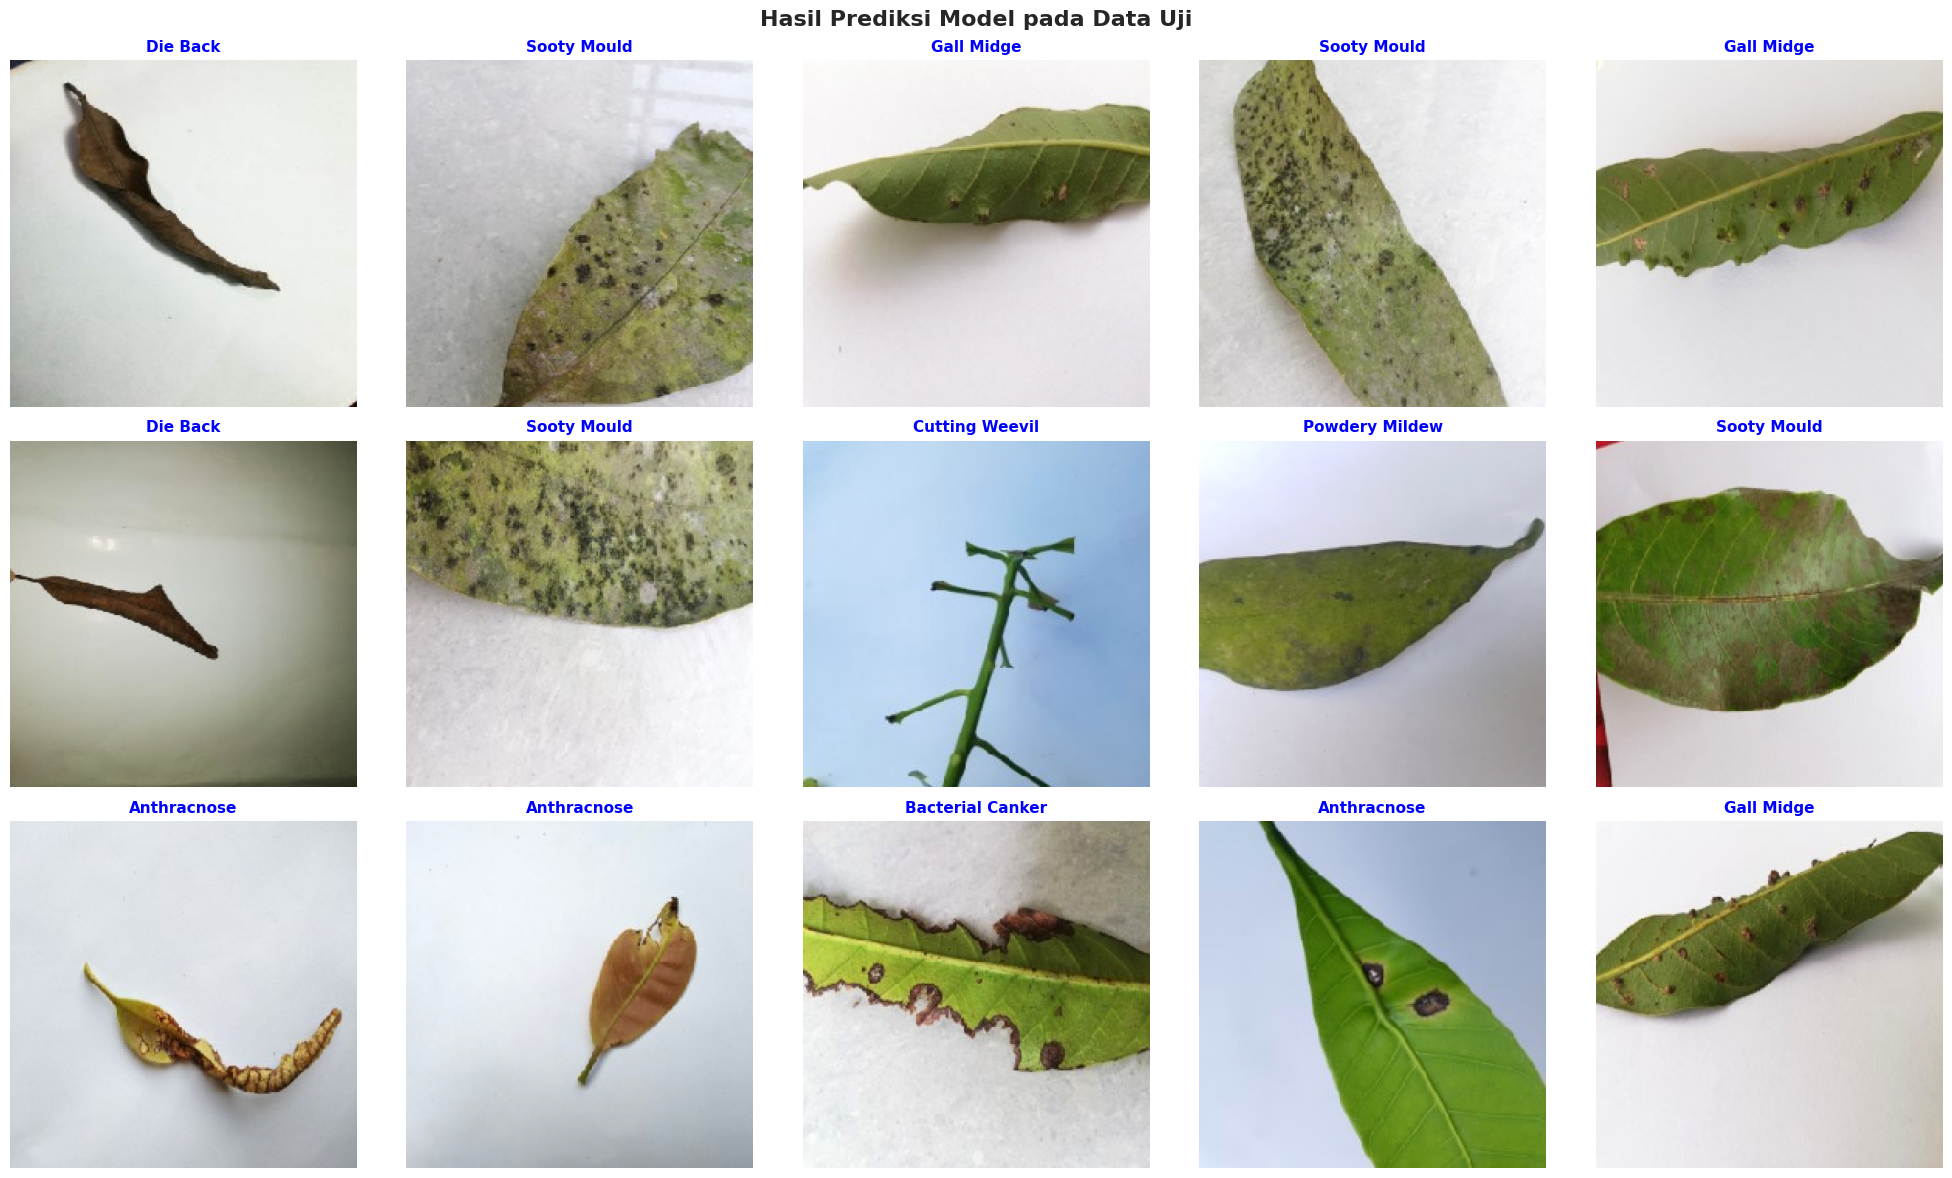

(None, 224, 224, 3)
✅ Model berhasil disimpan!


In [17]:
test_images, test_labels = next(test_generator)
preds = model.predict(test_images)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(test_labels, axis=1)

plt.figure(figsize=(20, 12))
for i in range(min(15, len(test_images))):
    plt.subplot(3, 5, i + 1)
    img = test_images[i]
    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)

    if pred_labels[i] == true_labels[i]:
        color = 'blue'
        title = f"{class_names[pred_labels[i]]}"
    else:
        color = 'red'
        title = f"Salah: {class_names[pred_labels[i]]}\n(Asli: {class_names[true_labels[i]]})"

    plt.title(title, color=color, fontsize=11, fontweight='bold')
    plt.axis('off')

plt.suptitle("Hasil Prediksi Model pada Data Uji", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print(model.input_shape)
model.save("Model_Mangga.keras")
print("✅ Model berhasil disimpan!")